<a href="https://colab.research.google.com/github/vittoriobu/neuroanalysis2026/blob/main/calcium_imaging_exercises_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calcium Imaging exercise 1 in colab



## Caiman setup / drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%mkdir -p neuroanalysis
%cd neuroanalysis

/content/neuroanalysis


In [3]:
# Install CaImAn
!git clone https://github.com/flatironinstitute/CaImAn.git
%cd 'CaImAn/'

Cloning into 'CaImAn'...
remote: Enumerating objects: 30638, done.
remote: Counting objects: 100% (7918/7918), done.
remote: Compressing objects: 100% (2593/2593), done.
remote: Total 30638 (delta 5477), reused 5326 (delta 5325), pack-reused 22720 (from 2)
Receiving objects: 100% (30638/30638), 646.46 MiB | 25.21 MiB/s, done.
Resolving deltas: 100% (20603/20603), done.
Updating files: 100% (228/228), done.
/content/neuroanalysis/CaImAn


In [ ]:

# %cd '/content/neuroanalysis/CaImAn/'

In [4]:
from datetime import datetime
import scipy.io as sio
import re
import os
import h5py
import csv
import tensorflow as tf
import time
import logging
import zipfile
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use('default')
import numpy as np
from moviepy.editor import *
import smtplib

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [5]:
!pip install jupyterlab numpy scipy matplotlib seaborn PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.4 MB/s eta 0:00:00


In [6]:
!pip install -e .

Obtaining file:///content/neuroanalysis/CaImAn
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.9/174.9 MB 6.5 MB/s e

In [8]:
%cd /content/neuroanalysis
! git clone https://github.com/neural-data-science-course/neural-data.git

/content/neuroanalysis
Cloning into 'neural-data'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 238 (delta 38), reused 51 (delta 18), pack-reused 137 (from 1)
Receiving objects: 100% (238/238), 41.59 MiB | 20.99 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [9]:
%cd neural-data

/content/neuroanalysis/neural-data


In [10]:
%cd 02-calcium_imaging

/content/neuroanalysis/neural-data/02-calcium_imaging


In [13]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

import sys
# Add the CaImAn directory to sys.path
sys.path.append(os.path.abspath('/content/neuroanalysis/CaImAn'))

# CaImAn functions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

# Original sys.path append for local code
sys.path.append(os.path.abspath("code"))
from utils import download_data
import auxiliary_functions as aux

import seaborn as sns
sns.set_theme(context='notebook', style='white', font_scale=1.5)

In [15]:
# download data for the lesson (this can take a few minutes)
# download_data('https://surfdrive.surf.nl/index.php/s/HeYXPdvMO87fbq7')

#!!!! as of 27/4/2026 the link didn't work, I asked around to send the original files to me

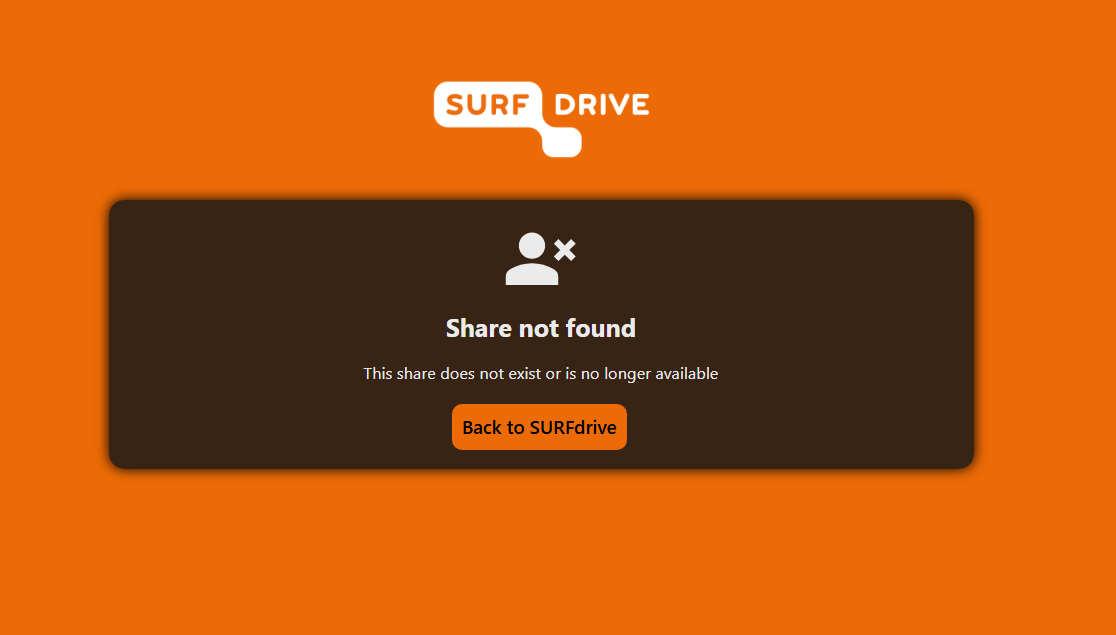

## Load and visualize the video

In [19]:
# set path to video of the full field of view
input_tif_file_path_FOV = '/content/drive/MyDrive/data/calcium_video.tif'
input_tif_file_path = '/content/drive/MyDrive/data/caiman_video_trial_0.tif'

In [20]:
FOV = cm.load(input_tif_file_path_FOV)  # load video with complete field of view (FOV)

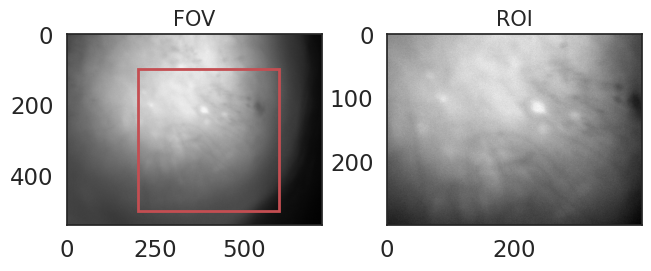

In [21]:
# visualization of the FOV and the ROI
aux.plot_FOV(FOV_file=input_tif_file_path_FOV, ROI_file=input_tif_file_path)

## Summary Images

In [22]:
# load movie and compute summary images with caiman functions
original_movie = cm.load(input_tif_file_path)
mean_image = cm.summary_images.mean_image(input_tif_file_path)
correlation_image, pnr_image = cm.summary_images.correlation_pnr(original_movie, swap_dim=False)

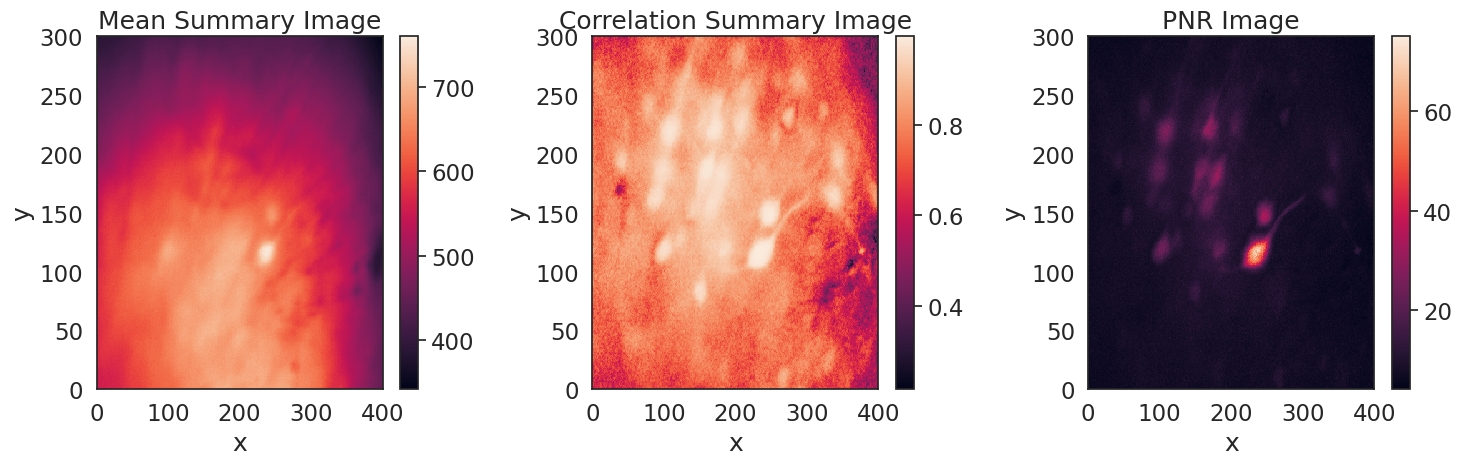

In [23]:
# Plot summary images
figure, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('Mean Summary Image')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].set_title('Correlation Summary Image')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y'); axes[2].set_title('PNR Image')

mesh0 = axes[0].pcolormesh(mean_image)
mesh1 = axes[1].pcolormesh(correlation_image)
mesh2 = axes[2].pcolormesh(pnr_image)

figure.colorbar(mesh0, ax=axes[0])
figure.colorbar(mesh1, ax=axes[1])
figure.colorbar(mesh2, ax=axes[2])
plt.tight_layout()

------------
## Exercise 1 : Image characteristics

### Exercise 1A - Distinguishing pixels

Select a set of N random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are chosen from an active neuron, you will be able to see the calcium transient dynamic. Try this a few times to appreciate the results.

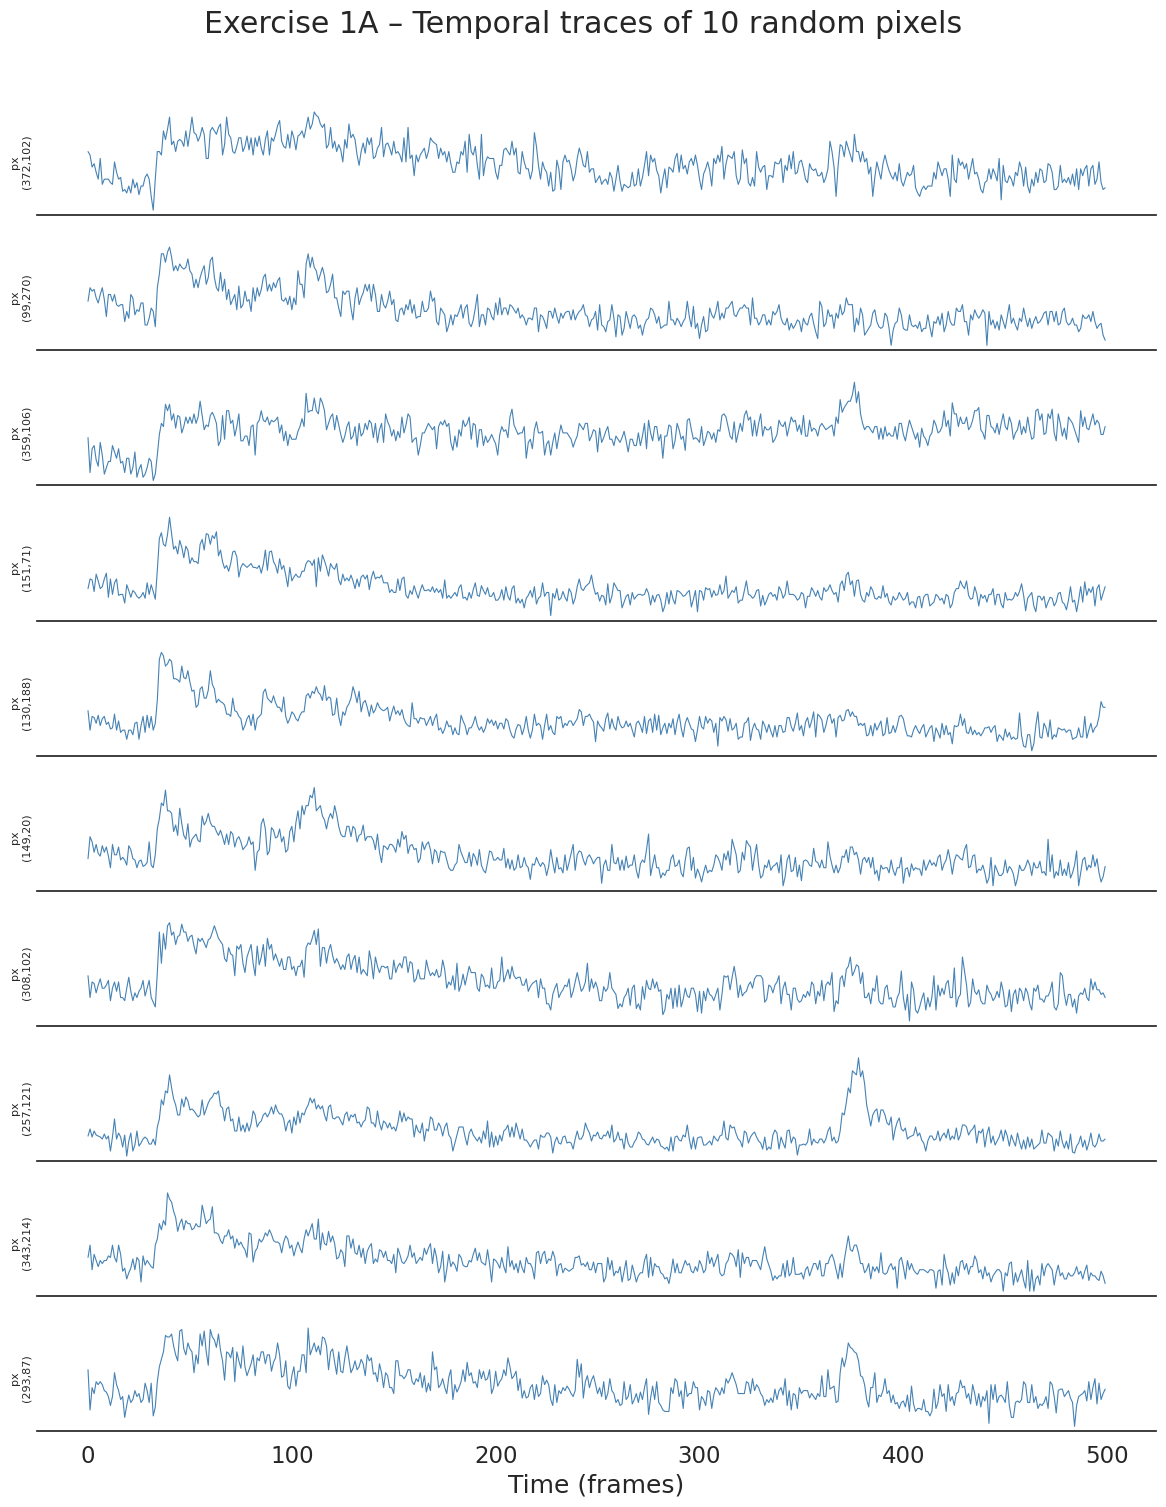

In [25]:
# Exercise 1A , Temporal traces of random pixels

N = 10  # number of random pixels to sample
n_frames, height, width = original_movie.shape

# randomly select N pixel coordinates within the ROI
np.random.seed(42)  # change or remove seed to get different pixels each run
random_y = np.random.randint(0, height, size=N)
random_x = np.random.randint(0, width, size=N)

# extract temporal traces for each selected pixel
pixel_traces = [original_movie[:, random_y[i], random_x[i]] for i in range(N)]

# plot temporal traces
figure, axes = plt.subplots(N, 1, figsize=(12, N * 1.5), sharex=True)
time_axis = np.arange(n_frames)
for i in range(N):
    axes[i].plot(time_axis, pixel_traces[i], lw=0.8, color='steelblue')
    axes[i].set_ylabel(f'px\n({random_x[i]},{random_y[i]})', fontsize=8)
    axes[i].set_yticks([])
    sns.despine(ax=axes[i], left=True)
axes[-1].set_xlabel('Time (frames)')
figure.suptitle(f'Exercise 1A – Temporal traces of {N} random pixels', y=1.01)
plt.tight_layout()

### Exercise 1 b : temporal Statistics of Pixel Activation

For the selected pixels, plot the histogram of pixel value. What are the differences in different regions, and how can that help to distinguish a pixel that belongs to a neuron from a background pixel?



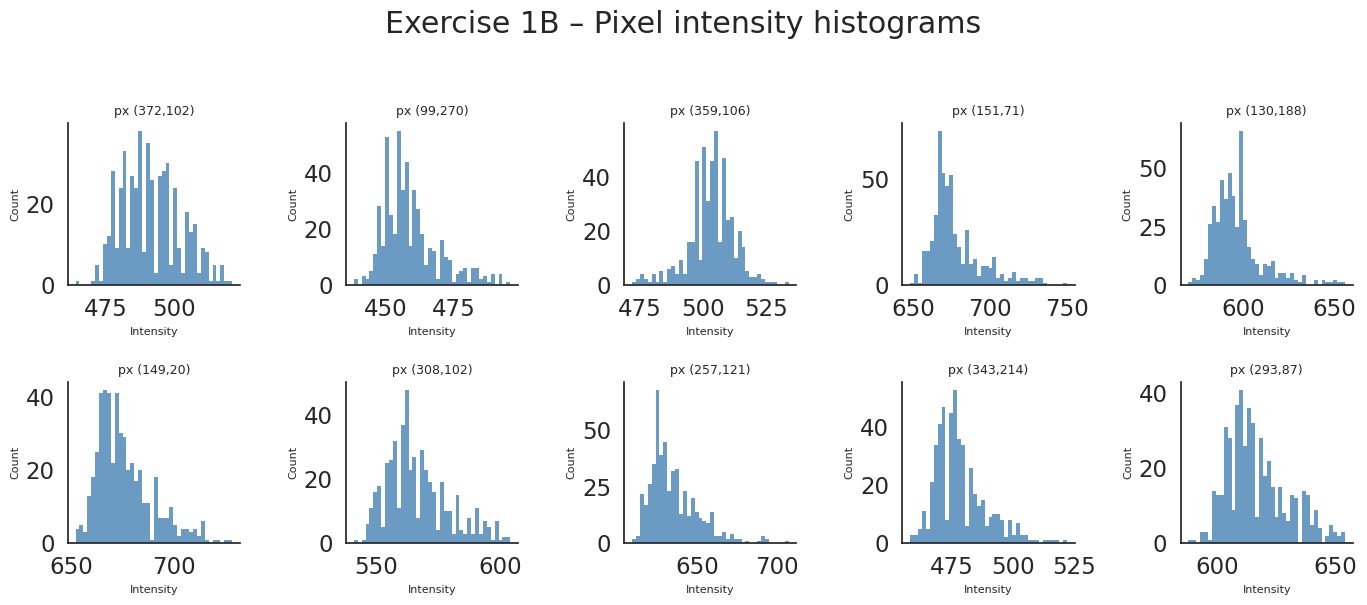

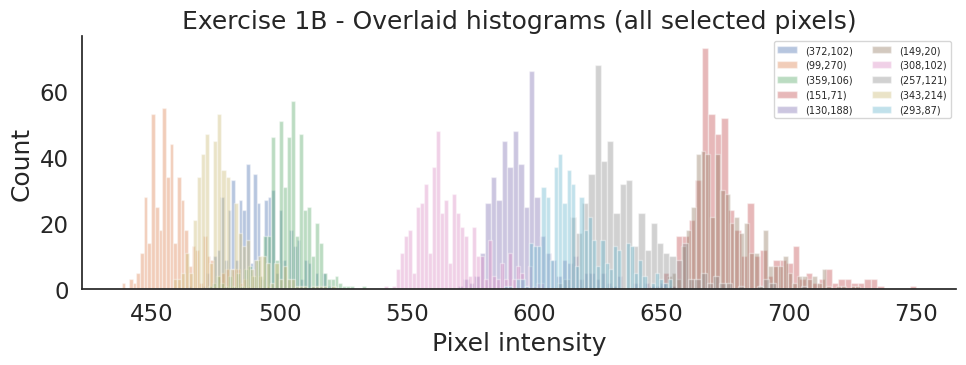

In [28]:
# Exercise 1B - Histograms of pixel values for the selected pixels

figure, axes = plt.subplots(2, N // 2, figsize=(14, 6), sharey=False)
axes = axes.flatten()

for i in range(N):
    axes[i].hist(pixel_traces[i], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'px ({random_x[i]},{random_y[i]})', fontsize=9)
    axes[i].set_xlabel('Intensity', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    sns.despine(ax=axes[i])

figure.suptitle('Exercise 1B – Pixel intensity histograms', y=1.02)
plt.tight_layout()

# overlay all histograms for comparison
figure2, ax2 = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax2.hist(pixel_traces[i], bins=40, alpha=0.4,
             label=f'({random_x[i]},{random_y[i]})')
ax2.set_xlabel('Pixel intensity')
ax2.set_ylabel('Count')
ax2.set_title('Exercise 1B - Overlaid histograms (all selected pixels)')
ax2.legend(fontsize=7, ncol=2)
sns.despine()
plt.tight_layout()